# **ESD Dataset Complete Experiments**

# **1) K-Nearest Neighbors (KNN)**

Saving esd.csv to esd.csv
Loaded shape: (520, 17)

Train metrics:
Accuracy: 0.9615  Precision: 0.9878  Recall: 0.9492  F1: 0.9681
Classification report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       160
           1       0.99      0.95      0.97       256

    accuracy                           0.96       416
   macro avg       0.96      0.97      0.96       416
weighted avg       0.96      0.96      0.96       416



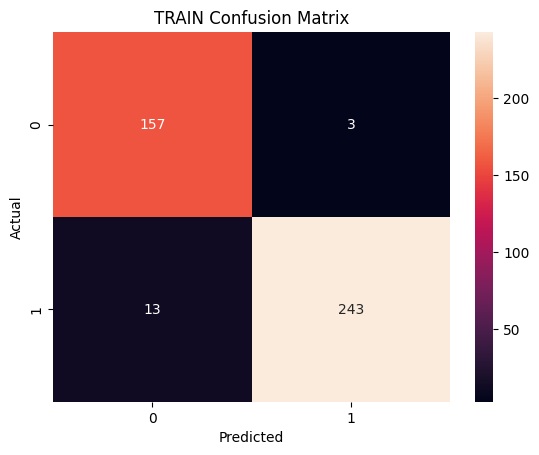


Test metrics:
Accuracy: 0.9327  Precision: 0.9831  Recall: 0.9062  F1: 0.9431
Classification report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92        40
           1       0.98      0.91      0.94        64

    accuracy                           0.93       104
   macro avg       0.92      0.94      0.93       104
weighted avg       0.94      0.93      0.93       104



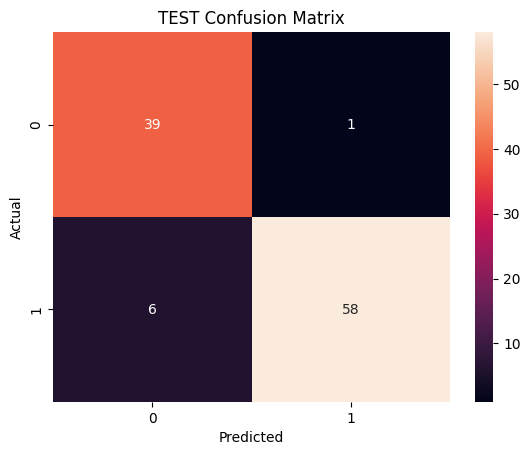

In [ ]:
# KNN classifier

# --- Installs (safe even if already installed) ---
!pip install -q imbalanced-learn xgboost

# --- Imports ---
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import Bunch

# --- Settings ---
RANDOM_STATE = 42
TRAIN_SIZE = 0.8
K_NEIGHBORS = 5
USE_SMOTE = False  # set True to enable SMOTE oversampling on train

# --- Helper: load dataset (tries common paths, else ask for upload) ---
def load_dataset():
    possible = ["/content/esd.csv", "/mnt/data/esd.csv", "esd.csv"]
    for p in possible:
        if os.path.exists(p):
            return pd.read_csv(p)
    # fallback to upload in Colab
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))
    return pd.read_csv(fname)

df = load_dataset()
print("Loaded shape:", df.shape)

# --- Preprocessing ---
# Standardize column names
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

# Map target
df['class'] = df['class'].map({'Positive':1, 'Negative':0})

# Binary columns mapping
binary_map = {'Yes':1, 'No':0}
for col in df.columns:
    if df[col].dtype == object and col != 'Gender':
        # Map Yes/No to 1/0 where applicable
        unique_vals = set(df[col].dropna().unique())
        if unique_vals <= set(['Yes','No']):
            df[col] = df[col].map(binary_map)

# Gender mapping
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

# Drop rows with any NaNs after mapping (shouldn't be necessary but safe)
df = df.dropna().reset_index(drop=True)

# Features & target
X = df.drop(columns=['class'])
y = df['class']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)

# Optional: SMOTE
if USE_SMOTE:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = sm.fit_resample(X_train, y_train)
    print("After SMOTE, train class counts:", np.bincount(y_train))

# Scaling (KNN benefits from scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=K_NEIGHBORS)
knn.fit(X_train_scaled, y_train)

# Evaluate
def report(model, Xtr, ytr, Xte, yte):
    for name, Xs, ys, label in [("Train", Xtr, ytr, "TRAIN"), ("Test", Xte, yte, "TEST")]:
        preds = model.predict(Xs)
        acc = accuracy_score(ys, preds)
        prec = precision_score(ys, preds, zero_division=0)
        rec = recall_score(ys, preds, zero_division=0)
        f1 = f1_score(ys, preds, zero_division=0)
        print(f"\n{name} metrics:")
        print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
        print("Classification report:\n", classification_report(ys, preds, zero_division=0))
        cm = confusion_matrix(ys, preds)
        sns.heatmap(cm, annot=True, fmt="d")
        plt.title(f"{label} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

report(knn, X_train_scaled, y_train, X_test_scaled, y_test)


## **2) Random Forest**


Train Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       160
           1       1.00      1.00      1.00       256

    accuracy                           1.00       416
   macro avg       1.00      1.00      1.00       416
weighted avg       1.00      1.00      1.00       416



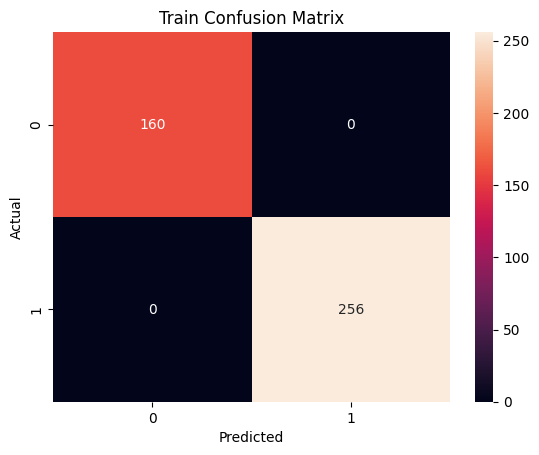


Test Accuracy: 0.9808
Precision: 0.9844
Recall: 0.9844
F1: 0.9844
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        40
           1       0.98      0.98      0.98        64

    accuracy                           0.98       104
   macro avg       0.98      0.98      0.98       104
weighted avg       0.98      0.98      0.98       104



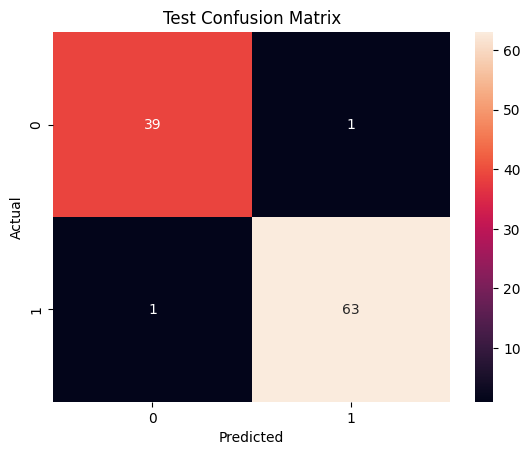


Top features:
                feature  importance
2             Polyuria    0.200154
3           Polydipsia    0.196939
1               Gender    0.106517
0                  Age    0.098158
4   sudden_weight_loss    0.067329
12     partial_paresis    0.048127
14            Alopecia    0.044714
6           Polyphagia    0.033732
10        Irritability    0.033721
9              Itching    0.033013


In [ ]:
# Random Forest classifier
!pip install -q imbalanced-learn

import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TRAIN_SIZE = 0.8
USE_SMOTE = False  # enable if desired

def load_dataset():
    possible = ["/content/esd.csv", "/mnt/data/esd.csv", "esd.csv"]
    for p in possible:
        if os.path.exists(p):
            return pd.read_csv(p)
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))
    return pd.read_csv(fname)

df = load_dataset()
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df['class'] = df['class'].map({'Positive':1, 'Negative':0})
binary_map = {'Yes':1,'No':0}
for col in df.columns:
    if df[col].dtype == object and col != 'Gender':
        unique_vals = set(df[col].dropna().unique())
        if unique_vals <= set(['Yes','No']):
            df[col] = df[col].map(binary_map)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df = df.dropna().reset_index(drop=True)

X = df.drop(columns=['class'])
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)

if USE_SMOTE:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = sm.fit_resample(X_train, y_train)

# Scaling (RF doesn't require scaling but safe)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced')
rf.fit(X_train_s, y_train)

def evaluate(m, Xtr, ytr, Xte, yte):
    for name, Xs, ys in [("Train", Xtr, ytr), ("Test", Xte, yte)]:
        preds = m.predict(Xs)
        print(f"\n{name} Accuracy: {accuracy_score(ys, preds):.4f}")
        print(f"Precision: {precision_score(ys, preds, zero_division=0):.4f}")
        print(f"Recall: {recall_score(ys, preds, zero_division=0):.4f}")
        print(f"F1: {f1_score(ys, preds, zero_division=0):.4f}")
        print("Classification report:\n", classification_report(ys, preds, zero_division=0))
        cm = confusion_matrix(ys, preds)
        sns.heatmap(cm, annot=True, fmt="d")
        plt.title(f"{name} Confusion Matrix")
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        plt.show()

evaluate(rf, X_train_s, y_train, X_test_s, y_test)

# Feature importances
importances = rf.feature_importances_
feat_names = X.columns.tolist()
imp_df = pd.DataFrame({'feature':feat_names, 'importance':importances}).sort_values('importance', ascending=False)
print("\nTop features:\n", imp_df.head(10))


# **3) Voting Classifier (ensemble of LogisticRegression, RandomForest, KNN)**


Train Accuracy: 0.9832
Precision: 0.9882
Recall: 0.9844
F1: 0.9863
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       160
           1       0.99      0.98      0.99       256

    accuracy                           0.98       416
   macro avg       0.98      0.98      0.98       416
weighted avg       0.98      0.98      0.98       416



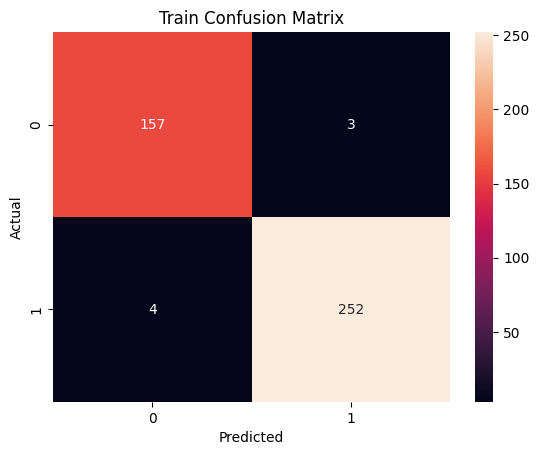


Test Accuracy: 0.9423
Precision: 0.9833
Recall: 0.9219
F1: 0.9516
Classification report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93        40
           1       0.98      0.92      0.95        64

    accuracy                           0.94       104
   macro avg       0.93      0.95      0.94       104
weighted avg       0.95      0.94      0.94       104



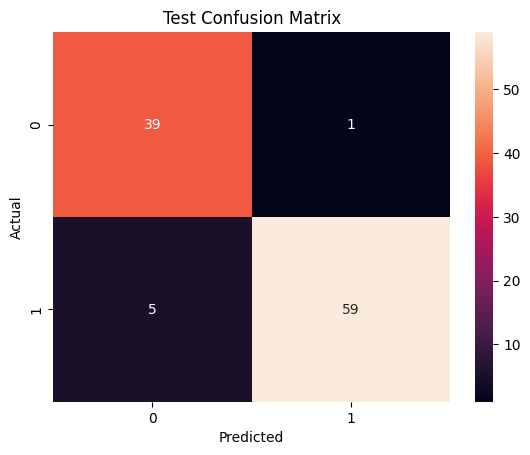

In [ ]:
# Voting Classifier

!pip install -q imbalanced-learn

import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TRAIN_SIZE = 0.8
USE_SMOTE = False

def load_dataset():
    possible = ["/content/esd.csv", "/mnt/data/esd.csv", "esd.csv"]
    for p in possible:
        if os.path.exists(p):
            return pd.read_csv(p)
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))
    return pd.read_csv(fname)

df = load_dataset()
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df['class'] = df['class'].map({'Positive':1, 'Negative':0})
binary_map = {'Yes':1,'No':0}
for col in df.columns:
    if df[col].dtype == object and col != 'Gender':
        unique_vals = set(df[col].dropna().unique())
        if unique_vals <= set(['Yes','No']):
            df[col] = df[col].map(binary_map)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df = df.dropna().reset_index(drop=True)

X = df.drop(columns=['class'])
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)

if USE_SMOTE:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = sm.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
rf = RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=RANDOM_STATE)
knn = KNeighborsClassifier(n_neighbors=5)

voting = VotingClassifier([
    ('lr', lr),
    ('rf', rf),
    ('knn', knn)
], voting='hard')  # hard voting for discrete predictions

voting.fit(X_train_s, y_train)

for name, Xs, ys in [("Train", X_train_s, y_train), ("Test", X_test_s, y_test)]:
    preds = voting.predict(Xs)
    print(f"\n{name} Accuracy: {accuracy_score(ys, preds):.4f}")
    print(f"Precision: {precision_score(ys, preds, zero_division=0):.4f}")
    print(f"Recall: {recall_score(ys, preds, zero_division=0):.4f}")
    print(f"F1: {f1_score(ys, preds, zero_division=0):.4f}")
    print("Classification report:\n", classification_report(ys, preds, zero_division=0))
    cm = confusion_matrix(ys, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()


# **4) XGBoost**

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:25:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Train Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       160
           1       1.00      1.00      1.00       256

    accuracy                           1.00       416
   macro avg       1.00      1.00      1.00       416
weighted avg       1.00      1.00      1.00       416



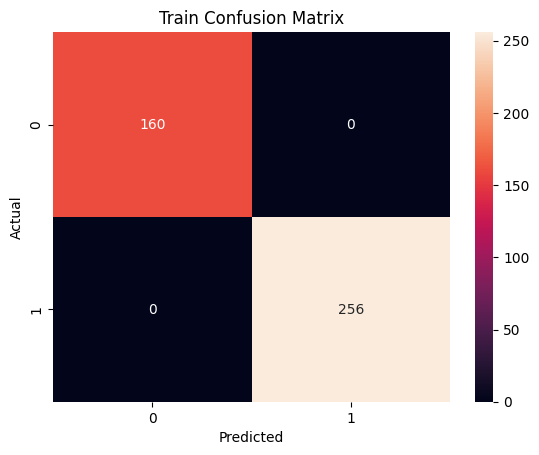


Test Accuracy: 0.9808
Precision: 1.0000
Recall: 0.9688
F1: 0.9841
Classification report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        40
           1       1.00      0.97      0.98        64

    accuracy                           0.98       104
   macro avg       0.98      0.98      0.98       104
weighted avg       0.98      0.98      0.98       104



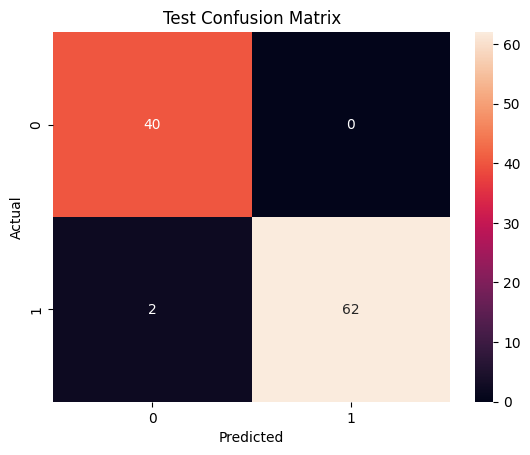


Top features:
              feature  importance
2           Polyuria    0.388998
3         Polydipsia    0.202729
1             Gender    0.077876
14          Alopecia    0.055878
11   delayed_healing    0.035776
10      Irritability    0.034810
9            Itching    0.029433
7     Genital_thrush    0.028724
15           Obesity    0.025368
13  muscle_stiffness    0.024437


In [ ]:
# XGBoost classifier

!pip install -q xgboost imbalanced-learn

import os
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TRAIN_SIZE = 0.8
USE_SMOTE = False

def load_dataset():
    possible = ["/content/esd.csv", "/mnt/data/esd.csv", "esd.csv"]
    for p in possible:
        if os.path.exists(p):
            return pd.read_csv(p)
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))
    return pd.read_csv(fname)

df = load_dataset()
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df['class'] = df['class'].map({'Positive':1, 'Negative':0})
binary_map = {'Yes':1,'No':0}
for col in df.columns:
    if df[col].dtype == object and col != 'Gender':
        unique_vals = set(df[col].dropna().unique())
        if unique_vals <= set(['Yes','No']):
            df[col] = df[col].map(binary_map)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df = df.dropna().reset_index(drop=True)

X = df.drop(columns=['class'])
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)

if USE_SMOTE:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = sm.fit_resample(X_train, y_train)

# Scaling not required for tree models
xgb = XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

for name, Xs, ys in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
    preds = xgb.predict(Xs)
    print(f"\n{name} Accuracy: {accuracy_score(ys, preds):.4f}")
    print(f"Precision: {precision_score(ys, preds, zero_division=0):.4f}")
    print(f"Recall: {recall_score(ys, preds, zero_division=0):.4f}")
    print(f"F1: {f1_score(ys, preds, zero_division=0):.4f}")
    print("Classification report:\n", classification_report(ys, preds, zero_division=0))
    cm = confusion_matrix(ys, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

# Show feature importances
importances = xgb.feature_importances_
feat_names = X.columns.tolist()
imp_df = pd.DataFrame({'feature':feat_names, 'importance':importances}).sort_values('importance', ascending=False)
print("\nTop features:\n", imp_df.head(10))


#**5) KMeans + Decision Tree (Used KMeans cluster label as extra feature, then DecisionTree classifier)**


Train Accuracy: 0.9928
Precision: 1.0000
Recall: 0.9883
F1: 0.9941
Classification report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       160
           1       1.00      0.99      0.99       256

    accuracy                           0.99       416
   macro avg       0.99      0.99      0.99       416
weighted avg       0.99      0.99      0.99       416



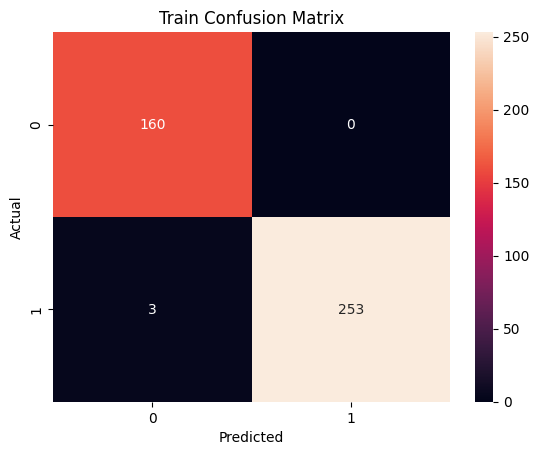


Test Accuracy: 0.9615
Precision: 1.0000
Recall: 0.9375
F1: 0.9677
Classification report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95        40
           1       1.00      0.94      0.97        64

    accuracy                           0.96       104
   macro avg       0.95      0.97      0.96       104
weighted avg       0.97      0.96      0.96       104



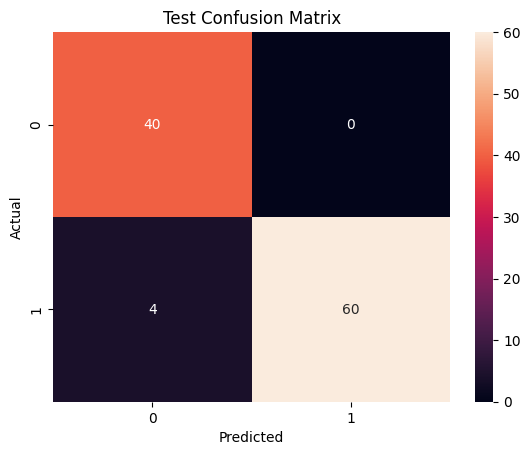

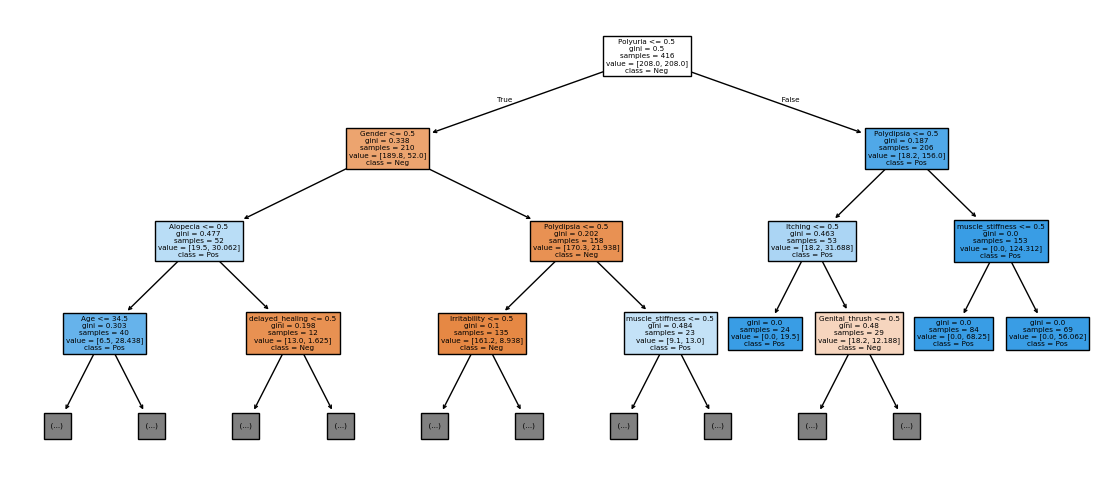

In [ ]:
# KMeans + DecisionTree

!pip install -q imbalanced-learn

import os
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TRAIN_SIZE = 0.8
N_CLUSTERS = 2
USE_SMOTE = False

def load_dataset():
    possible = ["/content/esd.csv", "/mnt/data/esd.csv", "esd.csv"]
    for p in possible:
        if os.path.exists(p):
            return pd.read_csv(p)
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))
    return pd.read_csv(fname)

df = load_dataset()
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df['class'] = df['class'].map({'Positive':1, 'Negative':0})
binary_map = {'Yes':1,'No':0}
for col in df.columns:
    if df[col].dtype == object and col != 'Gender':
        unique_vals = set(df[col].dropna().unique())
        if unique_vals <= set(['Yes','No']):
            df[col] = df[col].map(binary_map)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df = df.dropna().reset_index(drop=True)

X = df.drop(columns=['class'])
y = df['class']

# Standardize for clustering
scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(X)

# Fit KMeans on whole dataset to get stable clusters (common approach)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_scaled_all)
# append cluster label column
X_with_cluster = X.copy()
X_with_cluster['kmeans_cluster'] = cluster_labels

# Train-test split (stratify on y)
X_train, X_test, y_train, y_test = train_test_split(X_with_cluster, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)

if USE_SMOTE:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = sm.fit_resample(X_train, y_train)

# No scaling required for DecisionTree
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6, class_weight='balanced')
dt.fit(X_train, y_train)

for name, Xs, ys in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
    preds = dt.predict(Xs)
    print(f"\n{name} Accuracy: {accuracy_score(ys, preds):.4f}")
    print(f"Precision: {precision_score(ys, preds, zero_division=0):.4f}")
    print(f"Recall: {recall_score(ys, preds, zero_division=0):.4f}")
    print(f"F1: {f1_score(ys, preds, zero_division=0):.4f}")
    print("Classification report:\n", classification_report(ys, preds, zero_division=0))
    cm = confusion_matrix(ys, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

# Optional: plot a small tree
plt.figure(figsize=(14,6))
plot_tree(dt, feature_names=X_with_cluster.columns.tolist(), class_names=['Neg','Pos'], filled=True, max_depth=3)
plt.show()


# **6) KMeans + Principal Component Analysis (PCA)(We added KMeans cluster labels as a feature, then performed PCA, then classified using Logistic Regression)**


Train Accuracy: 0.8918
Precision: 0.9648
Recall: 0.8555
F1: 0.9068
Classification report:
               precision    recall  f1-score   support

           0       0.80      0.95      0.87       160
           1       0.96      0.86      0.91       256

    accuracy                           0.89       416
   macro avg       0.88      0.90      0.89       416
weighted avg       0.90      0.89      0.89       416



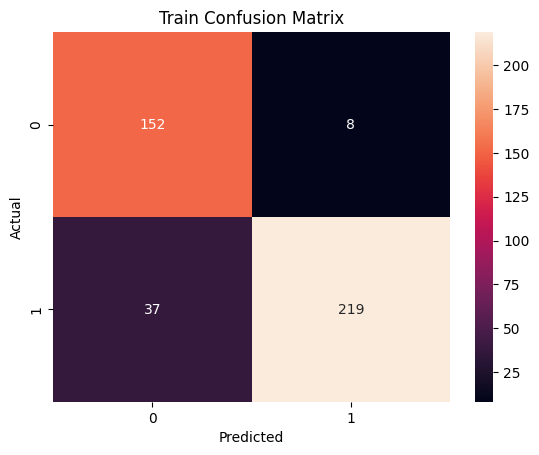


Test Accuracy: 0.9135
Precision: 1.0000
Recall: 0.8594
F1: 0.9244
Classification report:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90        40
           1       1.00      0.86      0.92        64

    accuracy                           0.91       104
   macro avg       0.91      0.93      0.91       104
weighted avg       0.93      0.91      0.91       104



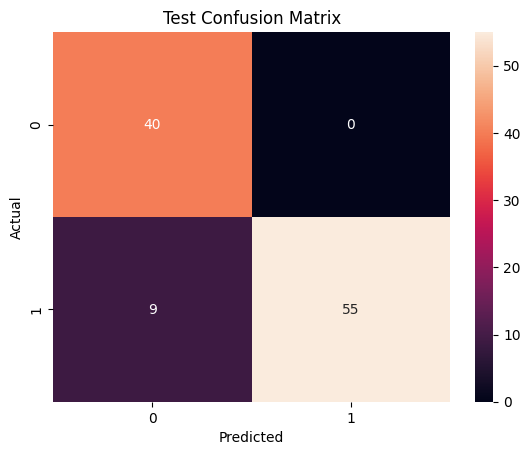


Explained variance ratio (first components): [0.25212235 0.13709204 0.08887685 0.07421858 0.05934061]


In [ ]:
# KMeans + PCA + Logistic Regression

!pip install -q imbalanced-learn

import os
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TRAIN_SIZE = 0.8
N_CLUSTERS = 2
PCA_COMPONENTS = 5
USE_SMOTE = False

def load_dataset():
    possible = ["/content/esd.csv", "/mnt/data/esd.csv", "esd.csv"]
    for p in possible:
        if os.path.exists(p):
            return pd.read_csv(p)
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))
    return pd.read_csv(fname)

df = load_dataset()
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df['class'] = df['class'].map({'Positive':1, 'Negative':0})
binary_map = {'Yes':1,'No':0}
for col in df.columns:
    if df[col].dtype == object and col != 'Gender':
        unique_vals = set(df[col].dropna().unique())
        if unique_vals <= set(['Yes','No']):
            df[col] = df[col].map(binary_map)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df = df.dropna().reset_index(drop=True)

X = df.drop(columns=['class'])
y = df['class']

# Scale before KMeans and PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_scaled)
X_with_cluster = pd.DataFrame(X_scaled, columns=X.columns)
X_with_cluster['kmeans_cluster'] = cluster_labels

# PCA
pca = PCA(n_components=min(PCA_COMPONENTS, X_with_cluster.shape[1]))
X_pca = pca.fit_transform(X_with_cluster)

# Train-test split on transformed features
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)

if USE_SMOTE:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = sm.fit_resample(X_train, y_train)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train, y_train)

for name, Xs, ys in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
    preds = lr.predict(Xs)
    print(f"\n{name} Accuracy: {accuracy_score(ys, preds):.4f}")
    print(f"Precision: {precision_score(ys, preds, zero_division=0):.4f}")
    print(f"Recall: {recall_score(ys, preds, zero_division=0):.4f}")
    print(f"F1: {f1_score(ys, preds, zero_division=0):.4f}")
    print("Classification report:\n", classification_report(ys, preds, zero_division=0))
    cm = confusion_matrix(ys, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

# PCA explained variance
print("\nExplained variance ratio (first components):", pca.explained_variance_ratio_)


#**7) Support Vector Machine (SVM)**


Train Accuracy: 0.9832
Precision: 0.9844
Recall: 0.9883
F1: 0.9864
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       160
           1       0.98      0.99      0.99       256

    accuracy                           0.98       416
   macro avg       0.98      0.98      0.98       416
weighted avg       0.98      0.98      0.98       416



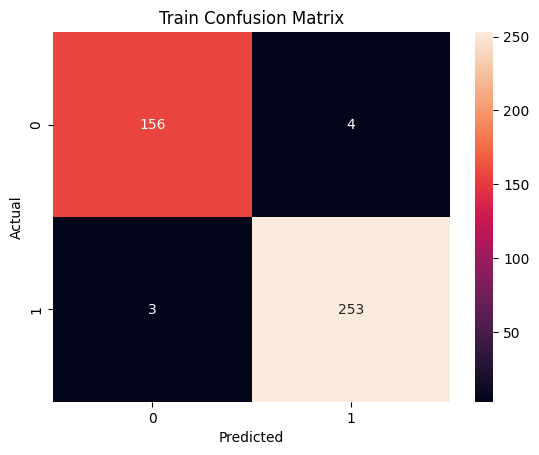


Test Accuracy: 0.9712
Precision: 0.9841
Recall: 0.9688
F1: 0.9764
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        40
           1       0.98      0.97      0.98        64

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104



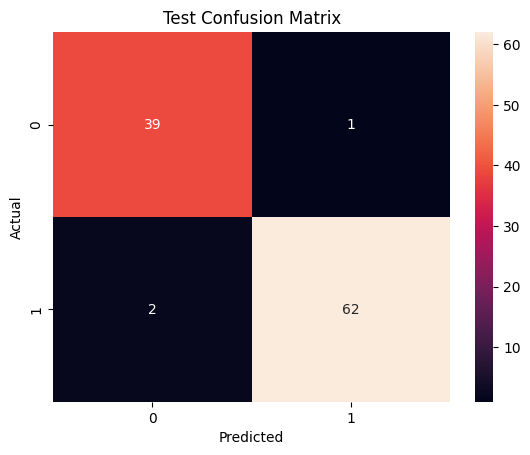

In [ ]:
# SVM classifier

!pip install -q imbalanced-learn

import os
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TRAIN_SIZE = 0.8
USE_SMOTE = False

def load_dataset():
    possible = ["/content/esd.csv", "/mnt/data/esd.csv", "esd.csv"]
    for p in possible:
        if os.path.exists(p):
            return pd.read_csv(p)
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))
    return pd.read_csv(fname)

df = load_dataset()
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df['class'] = df['class'].map({'Positive':1, 'Negative':0})
binary_map = {'Yes':1,'No':0}
for col in df.columns:
    if df[col].dtype == object and col != 'Gender':
        unique_vals = set(df[col].dropna().unique())
        if unique_vals <= set(['Yes','No']):
            df[col] = df[col].map(binary_map)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df = df.dropna().reset_index(drop=True)

X = df.drop(columns=['class'])
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)

if USE_SMOTE:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = sm.fit_resample(X_train, y_train)

# SVM requires scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

svc = SVC(kernel='rbf', probability=False, class_weight='balanced', random_state=RANDOM_STATE)
svc.fit(X_train_s, y_train)

for name, Xs, ys in [("Train", X_train_s, y_train), ("Test", X_test_s, y_test)]:
    preds = svc.predict(Xs)
    print(f"\n{name} Accuracy: {accuracy_score(ys, preds):.4f}")
    print(f"Precision: {precision_score(ys, preds, zero_division=0):.4f}")
    print(f"Recall: {recall_score(ys, preds, zero_division=0):.4f}")
    print(f"F1: {f1_score(ys, preds, zero_division=0):.4f}")
    print("Classification report:\n", classification_report(ys, preds, zero_division=0))
    cm = confusion_matrix(ys, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()


#**8) KMeans + SVM (Used KMeans cluster label as extra feature, then SVM classifier)**


Train Accuracy: 0.9808
Precision: 0.9844
Recall: 0.9844
F1: 0.9844
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       160
           1       0.98      0.98      0.98       256

    accuracy                           0.98       416
   macro avg       0.98      0.98      0.98       416
weighted avg       0.98      0.98      0.98       416



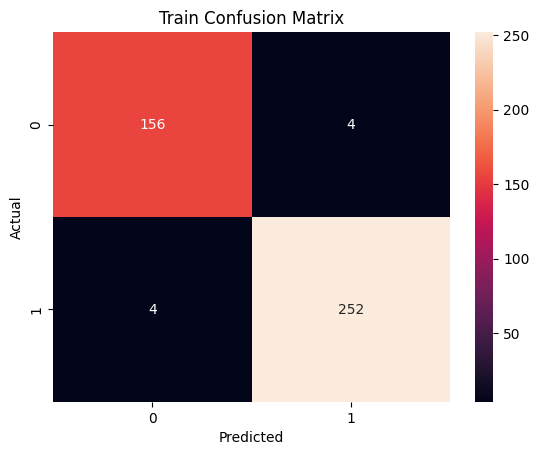


Test Accuracy: 0.9615
Precision: 0.9839
Recall: 0.9531
F1: 0.9683
Classification report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95        40
           1       0.98      0.95      0.97        64

    accuracy                           0.96       104
   macro avg       0.96      0.96      0.96       104
weighted avg       0.96      0.96      0.96       104



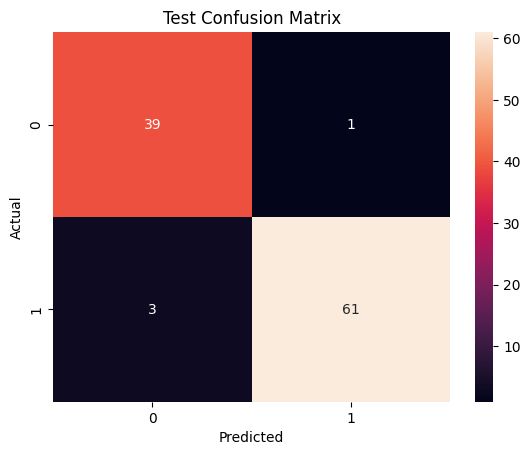

In [ ]:
# KMeans + SVM

!pip install -q imbalanced-learn

import os
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TRAIN_SIZE = 0.8
N_CLUSTERS = 2
USE_SMOTE = False

def load_dataset():
    possible = ["/content/esd.csv", "/mnt/data/esd.csv", "esd.csv"]
    for p in possible:
        if os.path.exists(p):
            return pd.read_csv(p)
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))
    return pd.read_csv(fname)

df = load_dataset()
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df['class'] = df['class'].map({'Positive':1, 'Negative':0})
binary_map = {'Yes':1,'No':0}
for col in df.columns:
    if df[col].dtype == object and col != 'Gender':
        unique_vals = set(df[col].dropna().unique())
        if unique_vals <= set(['Yes','No']):
            df[col] = df[col].map(binary_map)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df = df.dropna().reset_index(drop=True)

X = df.drop(columns=['class'])
y = df['class']

# Scale for clustering and SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(X_scaled)
X_with_cluster = pd.DataFrame(X_scaled, columns=X.columns)
X_with_cluster['kmeans_cluster'] = clusters

X_train, X_test, y_train, y_test = train_test_split(X_with_cluster, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)

if USE_SMOTE:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = sm.fit_resample(X_train, y_train)

# SVM - needs scaling; features are already scaled except cluster label; scale entire dataset again
scaler2 = StandardScaler()
X_train_s = scaler2.fit_transform(X_train)
X_test_s = scaler2.transform(X_test)

svc = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)
svc.fit(X_train_s, y_train)

for name, Xs, ys in [("Train", X_train_s, y_train), ("Test", X_test_s, y_test)]:
    preds = svc.predict(Xs)
    print(f"\n{name} Accuracy: {accuracy_score(ys, preds):.4f}")
    print(f"Precision: {precision_score(ys, preds, zero_division=0):.4f}")
    print(f"Recall: {recall_score(ys, preds, zero_division=0):.4f}")
    print(f"F1: {f1_score(ys, preds, zero_division=0):.4f}")
    print("Classification report:\n", classification_report(ys, preds, zero_division=0))
    cm = confusion_matrix(ys, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()


#**9) Feed Forward Neural Network (Keras)**

Epoch 1/80
12/12 - 2s - 155ms/step - accuracy: 0.6346 - loss: 0.6484 - val_accuracy: 0.8413 - val_loss: 0.5685
Epoch 2/80
12/12 - 0s - 10ms/step - accuracy: 0.8017 - loss: 0.5313 - val_accuracy: 0.8413 - val_loss: 0.4820
Epoch 3/80
12/12 - 0s - 10ms/step - accuracy: 0.8159 - loss: 0.4733 - val_accuracy: 0.8413 - val_loss: 0.4136
Epoch 4/80
12/12 - 0s - 12ms/step - accuracy: 0.8640 - loss: 0.3861 - val_accuracy: 0.8571 - val_loss: 0.3598
Epoch 5/80
12/12 - 0s - 10ms/step - accuracy: 0.8725 - loss: 0.3521 - val_accuracy: 0.8730 - val_loss: 0.3210
Epoch 6/80
12/12 - 0s - 10ms/step - accuracy: 0.8980 - loss: 0.3111 - val_accuracy: 0.9048 - val_loss: 0.2949
Epoch 7/80
12/12 - 0s - 10ms/step - accuracy: 0.9008 - loss: 0.2666 - val_accuracy: 0.9206 - val_loss: 0.2764
Epoch 8/80
12/12 - 0s - 10ms/step - accuracy: 0.9235 - loss: 0.2429 - val_accuracy: 0.9206 - val_loss: 0.2627
Epoch 9/80
12/12 - 0s - 10ms/step - accuracy: 0.9320 - loss: 0.2183 - val_accuracy: 0.9206 - val_loss: 0.2518
Epoch 10/

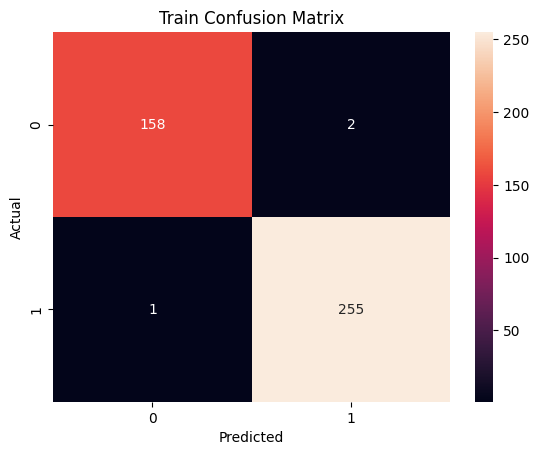


Test Accuracy: 0.9712
Precision: 0.9841
Recall: 0.9688
F1: 0.9764
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        40
           1       0.98      0.97      0.98        64

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104



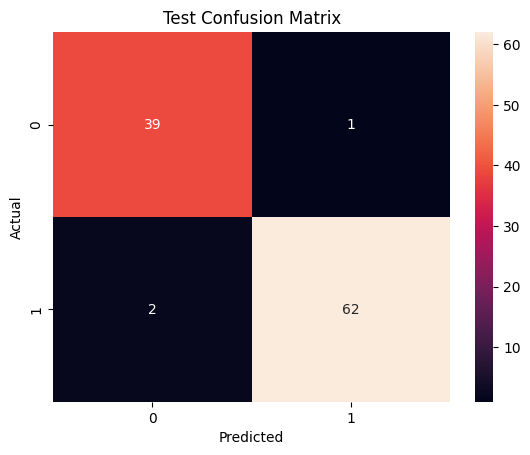

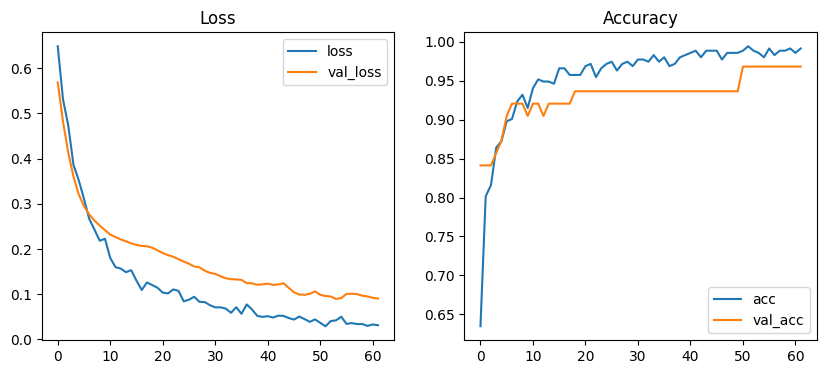

In [ ]:
# Feed-forward Neural Network (Keras)

!pip install -q imbalanced-learn
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

RANDOM_STATE = 42
TRAIN_SIZE = 0.8
USE_SMOTE = False
EPOCHS = 80
BATCH_SIZE = 32

def load_dataset():
    possible = ["/content/esd.csv", "/mnt/data/esd.csv", "esd.csv"]
    for p in possible:
        if os.path.exists(p):
            return pd.read_csv(p)
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))
    return pd.read_csv(fname)

df = load_dataset()
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df['class'] = df['class'].map({'Positive':1, 'Negative':0})
binary_map = {'Yes':1,'No':0}
for col in df.columns:
    if df[col].dtype == object and col != 'Gender':
        unique_vals = set(df[col].dropna().unique())
        if unique_vals <= set(['Yes','No']):
            df[col] = df[col].map(binary_map)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df = df.dropna().reset_index(drop=True)

X = df.drop(columns=['class'])
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)

if USE_SMOTE:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = sm.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Build model
tf.random.set_seed(RANDOM_STATE)
model = models.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit(X_train_s, y_train, validation_split=0.15, epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es], verbose=2)

# Predict
train_preds_prob = model.predict(X_train_s).ravel()
test_preds_prob = model.predict(X_test_s).ravel()
train_preds = (train_preds_prob >= 0.5).astype(int)
test_preds = (test_preds_prob >= 0.5).astype(int)

# Metrics
for name, preds, ys in [("Train", train_preds, y_train), ("Test", test_preds, y_test)]:
    print(f"\n{name} Accuracy: {accuracy_score(ys, preds):.4f}")
    print(f"Precision: {precision_score(ys, preds, zero_division=0):.4f}")
    print(f"Recall: {recall_score(ys, preds, zero_division=0):.4f}")
    print(f"F1: {f1_score(ys, preds, zero_division=0):.4f}")
    print("Classification report:\n", classification_report(ys, preds, zero_division=0))
    cm = confusion_matrix(ys, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

# Plot training history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='loss'); plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='acc'); plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.show()
